# Germany New Passenger Vehicle Registrations By Price

In Germany, the Kraftfahrtbundesamt (KBA) publishes monthly numbers on passenger vehicle registrations by model and fuel type in their FZ 8 publication:

Neuzulassungen von Kraftfahrzeugen und Kraftfahrzeuganhängern  
https://www.kba.de/DE/Statistik/Produktkatalog/produkte/Fahrzeuge/fz8/fz8_gentab.html

I wanted to see how the fraction of electric vehicles among new registrations varies with price.  
Price data for all models was acquired from the ADAC.

The data is combined to produce the CSV in `data/de/car_registrations_last_month_with_price_and_fractions.csv`

## Visualizations

Interactive: [Anteil Antriebsarten nach Listenpreis im August 2025 von 10 - 120k](https://www.datawrapper.de/_/PSqha/)
![Heavy vehicles in the german trucking market by fuel type in the last month](figures/de/PSqha-anteil-antriebsarten-nach-listenpreis-im-august-2025.png)

Interactive: [Anteil Antriebsarten nach Listenpreis im August 2025 von 15 - 75k](https://www.datawrapper.de/_/G1LsH/)
![Heavy vehicles in the german trucking market by fuel type in the last month](figures/de/G1LsH-anteil-antriebsarten-nach-listenpreis-im-august-2025-detail.png)


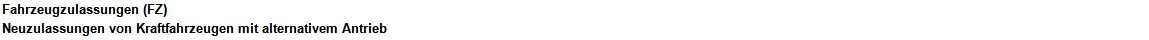
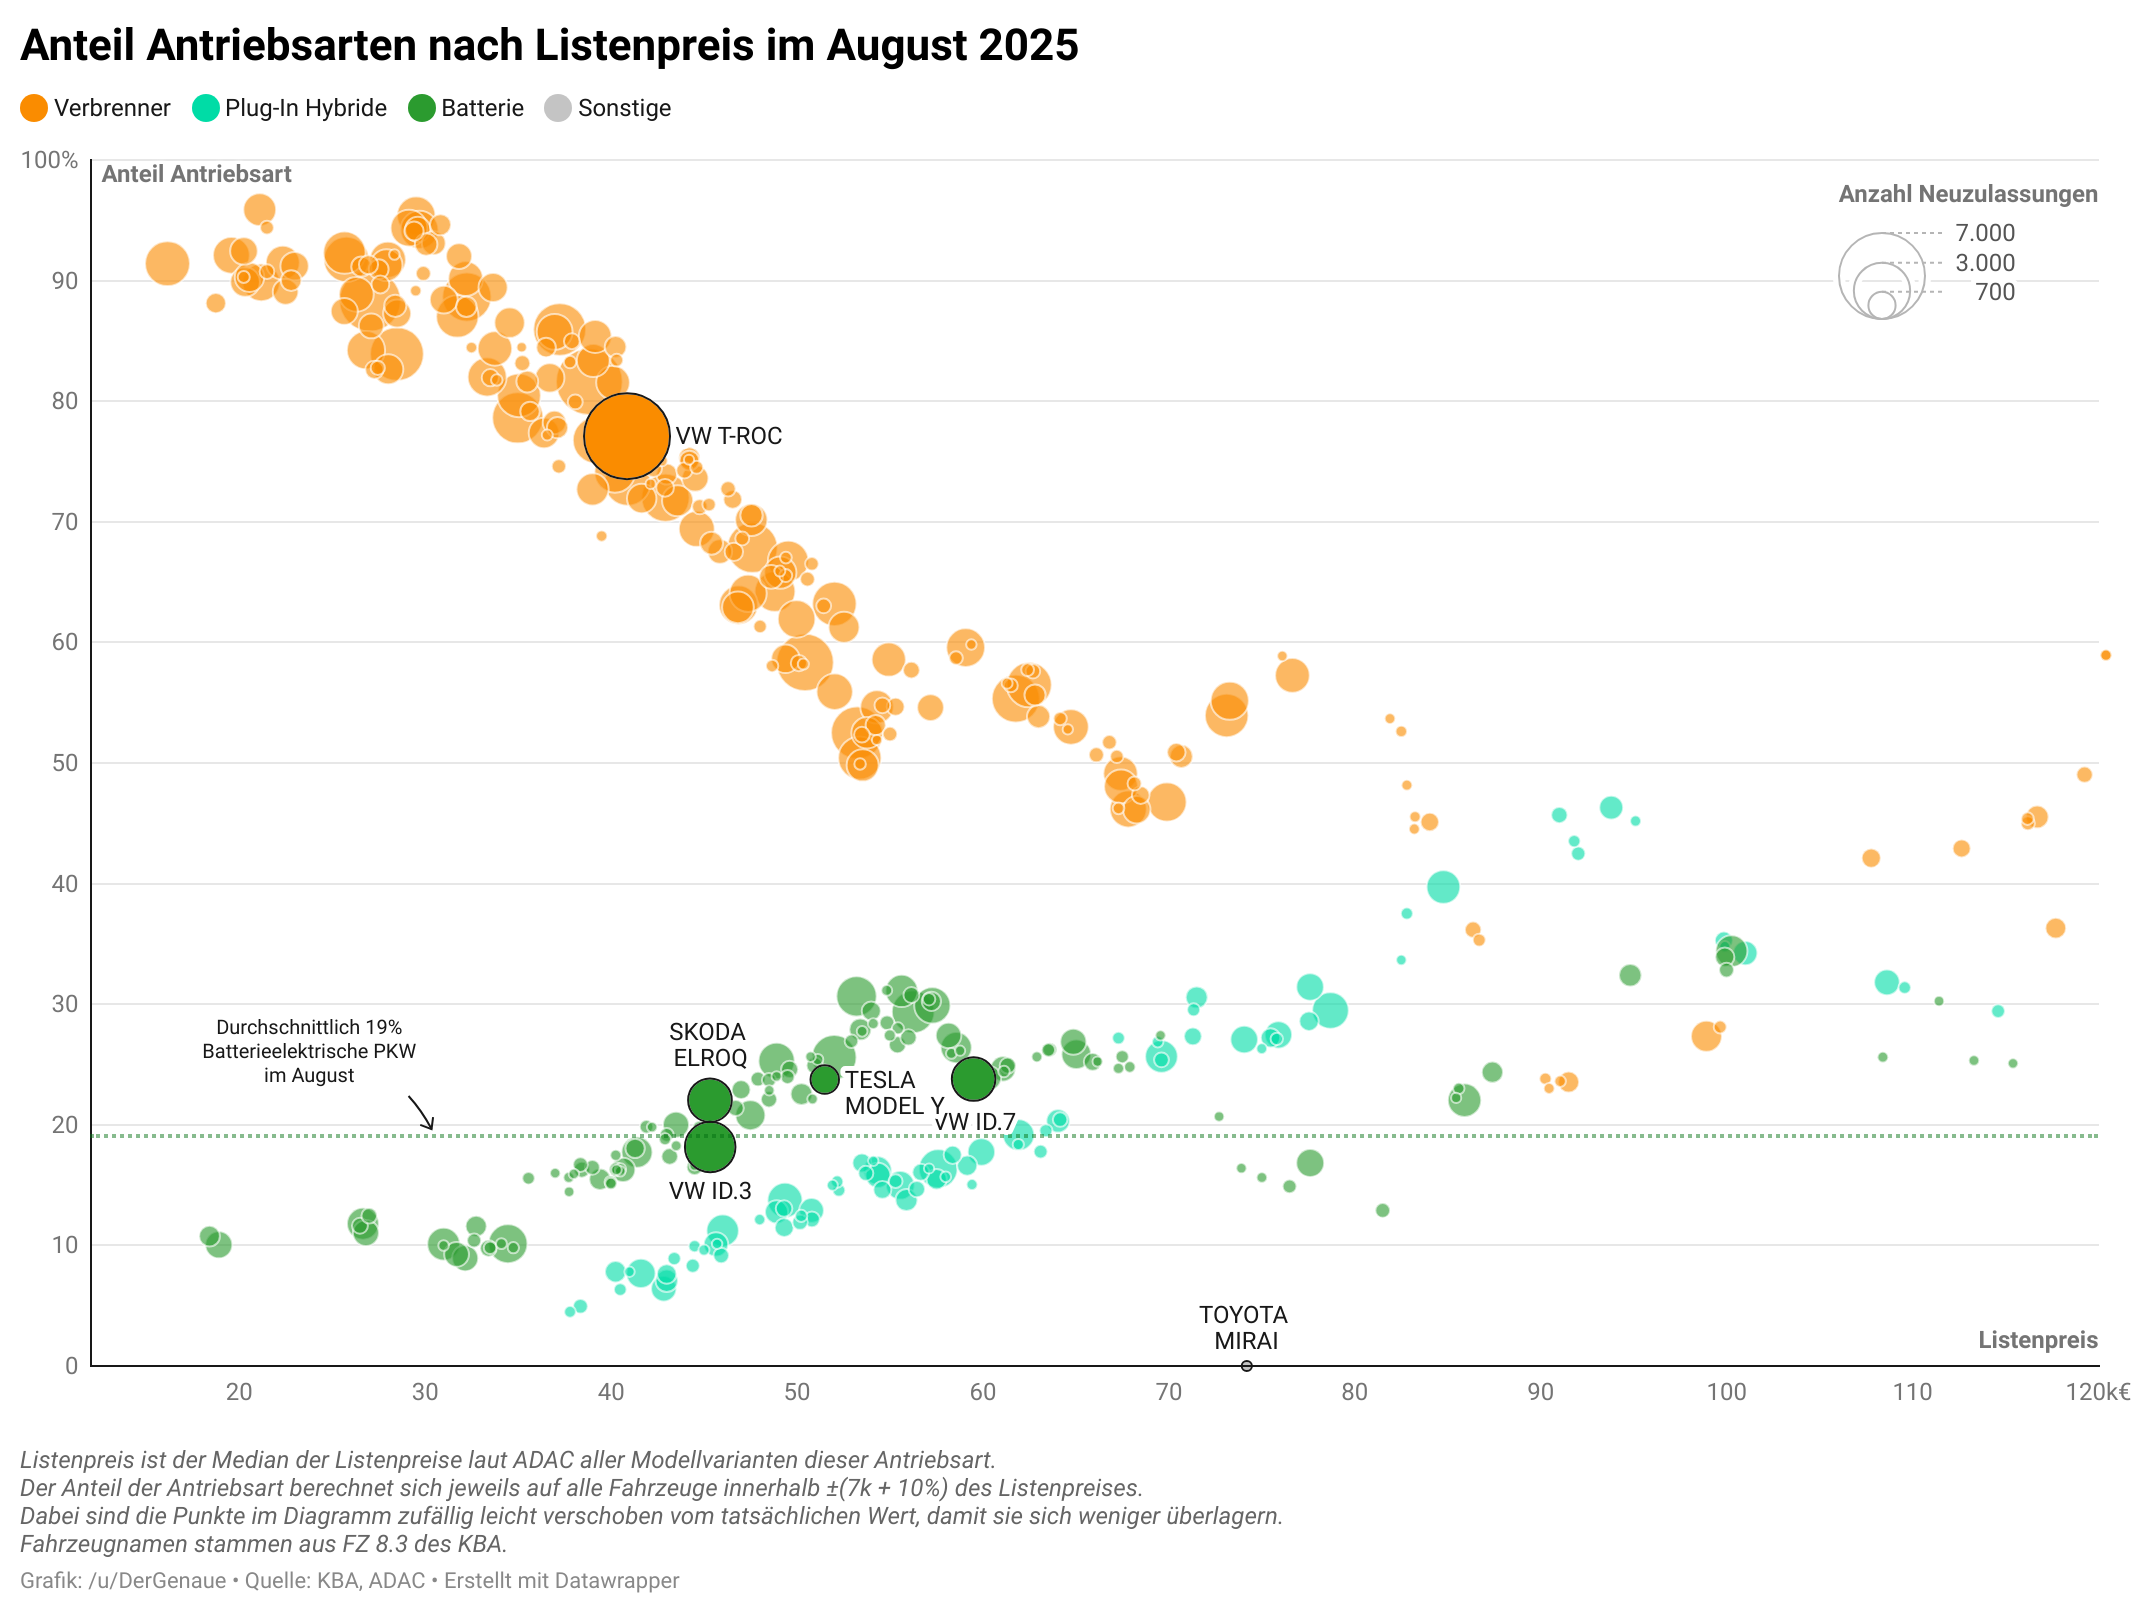

In [1]:
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import de_kba_datagrabber as kba
from adac_aggregate import get_aggregated_adac_price_data
from utils import PowerType
from plot_utils import draw_pie

In [2]:
kba.ensure_up_to_date()
ev_data_raw = kba.fz8_3_models_get()
adac_price_data = get_aggregated_adac_price_data()

September 2025


In [3]:
# Group everything under ICE; Other now only is Hydrogen pretty much
ev_data = ev_data_raw.copy()
ev_data[PowerType.ICE] = ev_data[PowerType.ICE_P] + ev_data[PowerType.ICE_D] + ev_data[PowerType.HEV] + ev_data[PowerType.CNG] + ev_data[PowerType.LPG]
#ev_data[PowerType.Gas] = ev_data[PowerType.CNG] + ev_data[PowerType.LPG]
#ev_data[PowerType.Other] += 
del ev_data[PowerType.ICE_P]
del ev_data[PowerType.ICE_D]
del ev_data[PowerType.CNG]
del ev_data[PowerType.LPG]
del ev_data[PowerType.HEV]
ev_data.stack()

DACIA SPRING    PHEV       0
                BEV      359
                Other      0
                ICE        0
FIAT 500        PHEV       0
                        ... 
MERCEDES AROCS  ICE        2
MERCEDES ATEGO  PHEV       0
                BEV        0
                Other      0
                ICE        1
Length: 1364, dtype: int64

In [4]:
adac_fuel_map = {
    'Super': PowerType.ICE,
    'Super Plus': PowerType.ICE,
    'Super / Super': PowerType.ICE,
    'Diesel': PowerType.ICE,
    'Super / Strom': PowerType.PHEV,
    'Super Plus / Strom': PowerType.PHEV,
    'Diesel / Strom': PowerType.PHEV,
    'Strom / Super': PowerType.PHEV,
    'Strom / Super Plus': PowerType.PHEV,
    'Flüssiggas': PowerType.ICE,
    'Erdgas / Super': PowerType.ICE,
    'Strom': PowerType.BEV,
    'Wasserstoff': PowerType.Other,
}

# Re-group by mapped fuel types and recalculate min, max, avg

mapped_index = pd.MultiIndex.from_tuples(
    [(name, adac_fuel_map.get(fuel)) for name, fuel in adac_price_data.index],
    names=['NAME', 'fuelType']
)

adac_price_regrouped = adac_price_data.copy()
adac_price_regrouped.index = mapped_index

# Recalculate stats per NAME and new fuelType
adac_price_regrouped = adac_price_regrouped.groupby(level=['NAME', 'fuelType']).agg(
    min_price=('min_price', 'min'),
    max_price=('max_price', 'max'),
    avg_price=('avg_price', 'mean'),
    med_price=('med_price', 'median'),
)

# Where there is PHEV data but no ICE data, copy PHEV data to ICE
# This is because the data unfortunately does not properly distinguish between PHEV and mild EVs, so if no ICE data is available, use PHEV data instead
to_append = []
for name in adac_price_regrouped.index.get_level_values('NAME').unique():
    has_ice = ((name, PowerType.ICE) in adac_price_regrouped.index)
    has_phev = ((name, PowerType.PHEV) in adac_price_regrouped.index)
    if (not has_ice) and has_phev:
        phev_row = adac_price_regrouped.loc[(name, PowerType.PHEV)]
        to_append.append(((name, PowerType.ICE), phev_row.to_dict()))

if to_append:
    add_df = pd.DataFrame.from_dict({k: v for k, v in to_append}, orient='index')
    add_df.index = pd.MultiIndex.from_tuples(add_df.index, names=['NAME', 'fuelType'])
    adac_price_regrouped = pd.concat([adac_price_regrouped, add_df], axis=0)

adac_price_regrouped.sort_index(inplace=True)
adac_price_regrouped


min_price max_price     avg_price med_price
NAME               fuelType                                            
AIWAYS U5          BEV        38973.0   46529.0       41780.0   40809.0
ALFA ROMEO GIULIA  ICE        56000.0   66500.0  61333.333333   61500.0
ALFA ROMEO JUNIOR  BEV        39500.0   48500.0       43750.0   43500.0
                   ICE        30450.0   40000.0       35480.0   36500.0
ALFA ROMEO STELVIO ICE        60600.0   71100.0  65933.333333   66100.0
...                               ...       ...           ...       ...
VW UP              BEV        21421.0   29995.0  24474.666667   23058.5
                   ICE         9975.0   20780.0  15360.481602  15409.75
XPENG G6           BEV        47600.0   51600.0       49600.0   49600.0
XPENG G9           BEV        59600.0   72600.0  65266.666667   63600.0
XPENG P7           BEV        49600.0   58600.0       54100.0   54100.0

[708 rows x 4 columns]

Now that both datasources have been brought into the same grouping and format, merge them

In [5]:
# For every non-zero entry in ev_data.stack(), add matching price columns from adac_price_regrouped; drop zeros
ev_full_data = ev_data.stack()
ev_full_data = ev_full_data[ev_full_data != 0]

# Ensure MultiIndex aligned with (NAME, fuelType)
ev_full_data.index = pd.MultiIndex.from_tuples(ev_full_data.index, names=['NAME', 'fuelType'])

# Join with price data and drop entries without price info
ev_full_data = ev_full_data.to_frame('registrations').join(adac_price_regrouped, how='left')

missing_data_entries = ev_full_data[ev_full_data['med_price'].isna()].copy()
missing_data_entries.sort_values(by=['registrations'], ascending=False, inplace=True)

ev_full_data.dropna(subset=['min_price', 'max_price', 'avg_price', 'med_price'], inplace=True)

missing_data_entries

,,registrations,min_price,max_price,avg_price,med_price
NAME,fuelType,,,,,
KIA EV4,BEV,228,NaN,NaN,NaN,NaN
FIAT ULYSSE,ICE,125,NaN,NaN,NaN,NaN
MAN TGE,ICE,100,NaN,NaN,NaN,NaN
BMW XM,PHEV,82,NaN,NaN,NaN,NaN
SONSTIGE,ICE,57,NaN,NaN,NaN,NaN
IVECO DAILY,ICE,46,NaN,NaN,NaN,NaN
PEUGEOT 3008,PHEV,29,NaN,NaN,NaN,NaN
LEAPMOTOR B10,BEV,22,NaN,NaN,NaN,NaN
BENTLEY CONTINENTAL,PHEV,16,NaN,NaN,NaN,NaN


In [6]:
# For every entry in ev_full_data, calculate the fraction of bev, ice and phev within 10k of the average_price
comparison_range_abs = 7000  # price range
comparison_range_factor = 0.1
# Jitter the data depending on how many vehicles of the same type there are nearby to make the dots easier to distinguish in visualizations
jitter_comp_range_abs = 2000  # consider cars within +- this range for jitter calculation
jitter_const = 0.005
jitter_factor = 0.7
price_to_use = 'med_price'

np.random.seed(42)

# Reset index to work with the data more easily
ev_full_data_w_fractions = ev_full_data.reset_index()

total_registrations = ev_full_data_w_fractions['registrations'].sum()

# Initialize the fraction columns
ev_full_data_w_fractions['frac_bev_nearby'] = 0.0
ev_full_data_w_fractions['frac_ice_nearby'] = 0.0
ev_full_data_w_fractions['frac_phev_nearby'] = 0.0
ev_full_data_w_fractions['frac_other_nearby'] = 0.0
ev_full_data_w_fractions['frac_nearby'] = 0.0
ev_full_data_w_fractions['frac_nearby_jittered'] = 0.0

# For each entry, calculate fractions within 10k of its average_price
for idx, row in ev_full_data_w_fractions.iterrows():
    target_price = row[price_to_use]
    comp_range = comparison_range_abs + comparison_range_factor * target_price

    # Find all entries within 10k of this price
    price_mask = (ev_full_data_w_fractions[price_to_use] >= target_price - comp_range) & (ev_full_data_w_fractions[price_to_use] <= target_price + comp_range)
    nearby_data = ev_full_data_w_fractions[price_mask]

    # Calculate total registrations for each fuel type within the range
    bev_total = nearby_data[nearby_data['fuelType'] == PowerType.BEV]['registrations'].sum()
    ice_total = nearby_data[nearby_data['fuelType'] == PowerType.ICE]['registrations'].sum()
    phev_total = nearby_data[nearby_data['fuelType'] == PowerType.PHEV]['registrations'].sum()
    other_total = nearby_data[nearby_data['fuelType'] == PowerType.Other]['registrations'].sum()
    
    jitter_nearby_data = ev_full_data_w_fractions[(ev_full_data_w_fractions[price_to_use] >= target_price - jitter_comp_range_abs) & (ev_full_data_w_fractions[price_to_use] <= target_price + jitter_comp_range_abs)]
    jitter_same_total = jitter_nearby_data[jitter_nearby_data['fuelType'] == row['fuelType']]['registrations'].sum()

    # Calculate total registrations within the range
    total_nearby = bev_total + ice_total + phev_total

    # Calculate fractions (avoid division by zero)
    if total_nearby > 0:
        ev_full_data_w_fractions.loc[idx, 'frac_bev_nearby'] = bev_total / total_nearby
        ev_full_data_w_fractions.loc[idx, 'frac_ice_nearby'] = ice_total / total_nearby
        ev_full_data_w_fractions.loc[idx, 'frac_phev_nearby'] = phev_total / total_nearby
        ev_full_data_w_fractions.loc[idx, 'frac_other_nearby'] = other_total / total_nearby
        frac_nearby = ev_full_data_w_fractions.loc[idx, f'frac_{row['fuelType'].lower()}_nearby']
        ev_full_data_w_fractions.loc[idx, 'frac_nearby'] = frac_nearby
        # jitter fraction value, but never outside [0,1] bounds
        ev_full_data_w_fractions.loc[idx, 'frac_nearby_jittered'] = (frac_nearby +
            min(max(
                ((jitter_same_total / total_registrations * jitter_factor + jitter_const) * (np.random.rand()*2-1)),
                -frac_nearby), 1-frac_nearby)
            )

# Set the index back and update ev_full_data
ev_full_data_w_fractions.set_index(['NAME', 'fuelType'], inplace=True)

ev_full_data_w_fractions.to_csv('data/de/car_registrations_last_month_with_price_and_fractions.csv')
ev_full_data_w_fractions

SyntaxError: f-string: unmatched '[' (2313153375.py, line 52)